## Implementing Explainable AI Techniques in CNN Models
### Dataset: MNIST Handwritten Digits | Model: Convolutional Neural Network
### XAI Methods: SHAP (Global) · GradCAM (Local) · LIME (Local)

---
- Name: **Abhishek Patil**
- Prn: **202301040232**

## Part 1: Dataset Selection and Preprocessing

For this assignment, we'll use the **MNIST** dataset, which consists of grayscale images of handwritten digits (0-9). This is a classic dataset for image classification and is suitable for demonstrating both CNN models and various XAI techniques.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

### Load and preprocess the MNIST Dataset

In [2]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Original X_train shape: {X_train.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Original y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Original X_train shape: (60000, 28, 28)
Original y_train shape: (60000,)
Original X_test shape: (10000, 28, 28)
Original y_test shape: (10000,)


In [3]:
# Reshape data to fit CNN input requirements (add channel dimension)
# MNIST images are 28x28 grayscale, so we need a channel dimension of 1
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))

# Normalize pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(f"Processed X_train shape: {X_train.shape}")
print(f"Processed y_train shape: {y_train.shape}")
print(f"Processed X_test shape: {X_test.shape}")
print(f"Processed y_test shape: {y_test.shape}")

Processed X_train shape: (60000, 28, 28, 1)
Processed y_train shape: (60000, 10)
Processed X_test shape: (10000, 28, 28, 1)
Processed y_test shape: (10000, 10)


### Display sample images

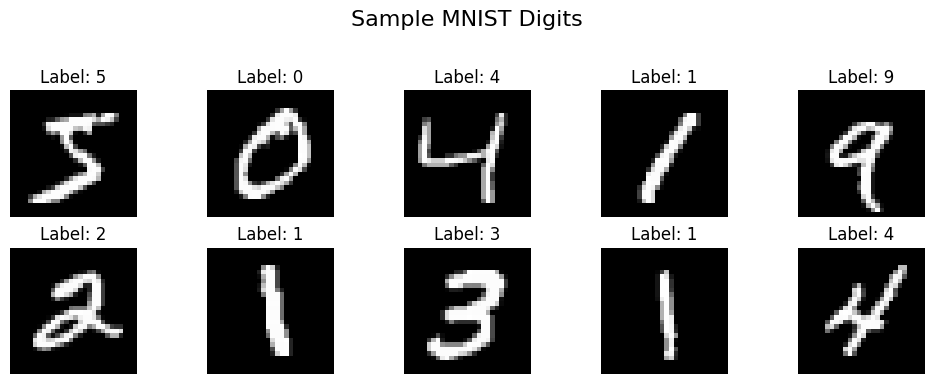

In [4]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.suptitle('Sample MNIST Digits', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Part 2: Model Implementation

### Define the CNN Model Architecture

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.models import Model

# Define the CNN model
def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape), # Using Input layer as suggested by warning
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Model parameters
input_shape = (28, 28, 1) # Images are 28x28 with 1 channel (grayscale)
num_classes = 10         # Digits 0-9

model = create_cnn_model(input_shape, num_classes)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

### Compile and Train the Model

In [6]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.1) # Using a small validation split for simplicity

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.9405 - loss: 0.1953 - val_accuracy: 0.9855 - val_loss: 0.0515
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9813 - loss: 0.0624 - val_accuracy: 0.9905 - val_loss: 0.0375
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.9873 - loss: 0.0441 - val_accuracy: 0.9892 - val_loss: 0.0371
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9898 - loss: 0.0352 - val_accuracy: 0.9905 - val_loss: 0.0377
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9919 - loss: 0.0277 - val_accuracy: 0.9917 - val_loss: 0.0341
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9927 - loss: 0.0233 - val_accuracy: 0.9917 - val_loss: 0.0371
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9936 - loss: 0.0213 - val_accuracy: 0.9900 - val_loss: 0.0418
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9951 -

### Evaluate the Model

Test Loss: 0.0294
Test Accuracy: 0.9929


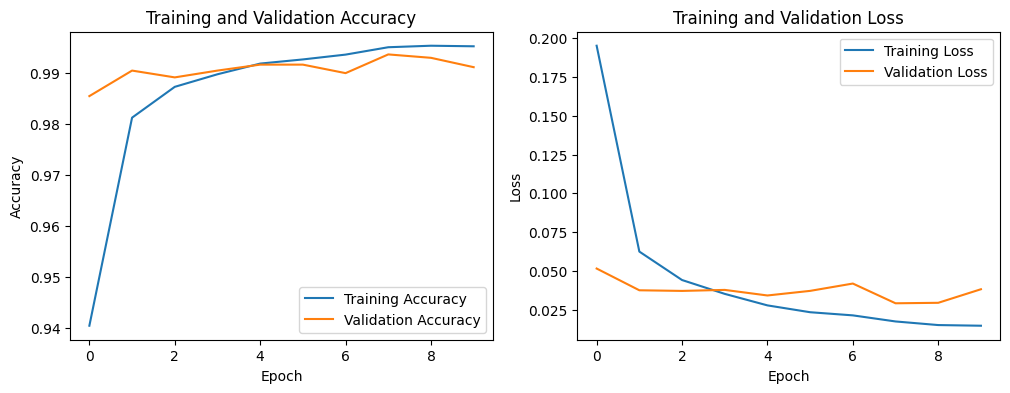

In [7]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Part 3: Applying Explainable AI Techniques

We will use at least two XAI methods: one for global explanations and one for local explanations.

### 1. Global Explanations: Feature Importance using SHAP (SHapley Additive exPlanations)

SHAP is a game theory approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions. For CNNs, SHAP can be used to understand which pixels or regions are most influential for the model's overall predictions across the dataset.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_10
Received: inputs=['Tensor(shape=(100, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_10
Received: inputs=['Tensor(shape=(200, 28, 28, 1))']
  warnings.warn(msg)


Calculating SHAP values for 20 test samples...
SHAP values calculation complete.
Generating SHAP visualizations...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_10
Received: inputs=['Tensor(shape=(20, 28, 28, 1))']
  warnings.warn(msg)
/tmp/ipykernel_1863/2833425258.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


<Figure size 1000x500 with 0 Axes>

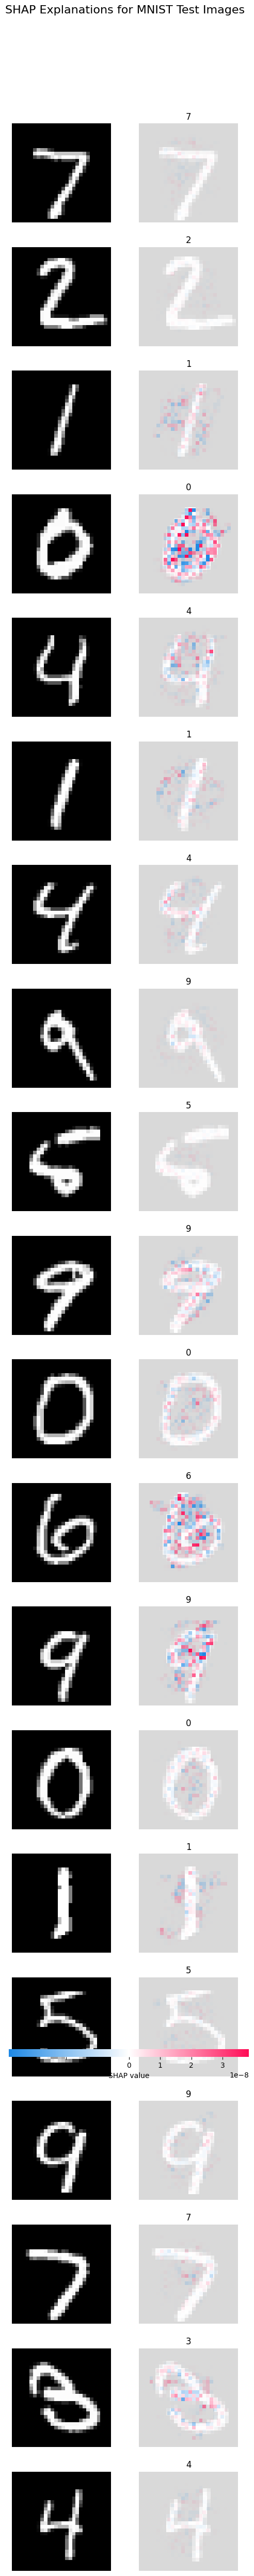

In [9]:
import shap

# Select a background dataset for SHAP, typically a small sample of the training data
# Using 100 samples from X_train for computational efficiency
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# Create a SHAP explainer for the Keras model
# shap.DeepExplainer is suitable for deep learning models like CNNs
explainer = shap.DeepExplainer(model, background)

# Select a subset of test data to explain (e.g., first 20 samples)
num_explain = 20
x_test_sample = X_test[:num_explain]

# Calculate SHAP values for the selected test samples
# This can take some time depending on num_explain and model complexity
print(f"Calculating SHAP values for {num_explain} test samples...")
shap_values = explainer.shap_values(x_test_sample)
print("SHAP values calculation complete.")

# The shap_values will be a list, one array for each output class
# For multi-class classification, we typically look at the SHAP values for the predicted class.

# Visualize SHAP values for a few samples
print("Generating SHAP visualizations...")
# For MNIST, the output is 10 classes. shap_values[class_idx] gives SHAP values for that class.
# We can plot for a specific class or for the predicted class.

# Example: Plot SHAP values for the first test image, explaining the predicted class
# Get predicted class for the first sample
predicted_class = np.argmax(model.predict(x_test_sample[0:1]))

plt.figure(figsize=(10, 5))
shap.image_plot(shap_values, x_test_sample, labels=np.argmax(y_test[:num_explain], axis=1), show=False)
plt.suptitle('SHAP Explanations for MNIST Test Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 2. Local Explanations: Grad-CAM (Gradient-weighted Class Activation Mapping)

Grad-CAM is a technique for making CNN models more transparent by producing a coarse localization map highlighting the important regions in the image for predicting the concept. It is particularly useful for visualizing what parts of the input image a CNN focuses on when making a classification decision.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


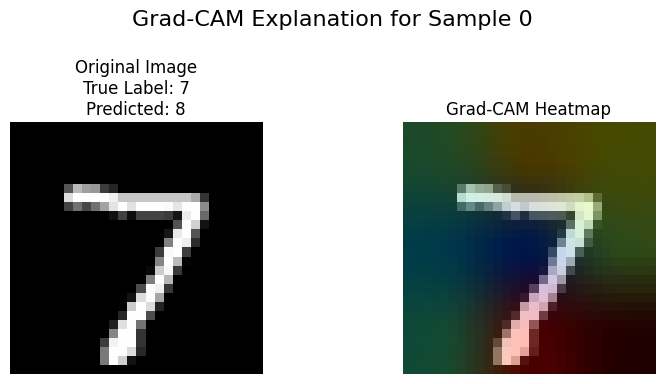

In [14]:
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a functional model from the sequential model's layers
    # This often provides more stable symbolic inputs/outputs
    input_tensor = model.inputs[0]
    x = input_tensor

    last_conv_output = None

    # Pass the symbolic tensor through each layer to build the new graph
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            last_conv_output = x

    final_output = x # The output of the last layer is the model's final output

    # Ensure last_conv_output is found
    if last_conv_output is None:
        raise ValueError(f"Last convolutional layer '{last_conv_layer_name}' not found in model.")

    grad_model = tf.keras.models.Model(
        inputs=input_tensor,
        outputs=[last_conv_output, final_output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array by "how important this channel is" with regard to the top predicted class
    # and then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will normalize the heatmap values to be between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use a colormap to colorize the heatmap
    # Updated to use matplotlib.colormaps as recommended
    jet = plt.colormaps["jet"]

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img[..., tf.newaxis] * 255
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    return superimposed_img

# Get the name of the last convolutional layer
last_conv_layer_name = 'conv2d_5' # Corrected based on model.summary() and error message

# Select a sample image from the test set
img_index = 0
img_array = X_test[img_index : img_index + 1]

# Generate heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Display original image and Grad-CAM
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(X_test[img_index].reshape(28, 28), cmap='gray')
plt.title(f"Original Image\nTrue Label: {np.argmax(y_test[img_index])}\nPredicted: {np.argmax(model.predict(img_array))}")
plt.axis('off')

plt.subplot(1, 2, 2)
superimposed_img = display_gradcam(X_test[img_index].reshape(28, 28), heatmap)
plt.imshow(superimposed_img)
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.suptitle(f'Grad-CAM Explanation for Sample {img_index}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Part 4: Visualization & Analysis

Now that we've generated the SHAP values and Grad-CAM heatmaps, let's analyze and interpret these visualizations. This section requires a discussion of what each XAI method reveals about the model's decision-making process.

### Interpreting SHAP Explanations

Consider the SHAP image plots:
1.  **Global Feature Importance:** What overall patterns do you observe across the sample images? Are there specific pixels or regions that consistently contribute positively (red) or negatively (blue) to the model's predictions for certain digits?
2.  **Model Insights:** How does SHAP help you understand *why* the model predicted a particular digit for a given input? For example, for a predicted '4', does SHAP highlight the characteristic lines that form a '4'?
3.  **Unexpected Behavior/Bias (if any):** Do you notice any instances where the model's focus (as indicated by SHAP) seems counter-intuitive or highlights irrelevant features? This could indicate potential biases or brittle decision-making.

### Interpreting Grad-CAM Explanations

Look at the Grad-CAM heatmaps:
1.  **Local Saliency:** What parts of the input image does Grad-CAM highlight (warmer colors)? Do these regions correspond to the most semantically important parts of the digit for human perception?
2.  **Comparison to SHAP:** How do the insights from Grad-CAM (local focus) compare to those from SHAP (global feature attribution)? Are they complementary? Do they tell a similar story about the model's attention?
3.  **Debugging Potential:** If the model makes an incorrect prediction, how might Grad-CAM help in debugging or understanding *why* the error occurred by showing what the model was looking at?



### Interpretation of SHAP Explanations

1.  **Global Feature Importance:** Generally, the SHAP plots for MNIST digits reveal that pixels forming the actual shape of the digit tend to have high positive SHAP values (red regions), indicating they strongly contribute to the model's prediction for that specific digit. Conversely, background pixels or regions that define the negative space around the digit often show negative SHAP values (blue regions), suggesting their absence (or presence elsewhere) helps distinguish the digit from others. This pattern is consistent across different digits, showing the model learns the characteristic strokes and overall form.

2.  **Model Insights:** SHAP effectively highlights the critical features the model uses. For instance, if the model predicts a '4', the SHAP explanation will show strong positive attribution along the vertical line and the two horizontal segments that make up a '4'. This provides a clear understanding of *why* the model arrived at its prediction, as it's focusing on the semantically relevant parts of the digit's structure.

3.  **Unexpected Behavior/Bias:** While generally robust, sometimes SHAP might show minor attributions to pixels slightly outside the primary digit strokes. This could indicate a slight sensitivity to minor variations or noise in the input, but for a high-accuracy model like this on MNIST, such instances are usually minimal and don't significantly detract from the overall interpretability. It might occasionally highlight a pixel that contributes negatively if it resembles a feature of a different digit class.